In [32]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.connection import get_db_connection


conn = get_db_connection()

if conn:
    query_tables = "SELECT table_name FROM information_schema.tables WHERE table_schema = 'raw';"
    tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
    
    all_data = {}

    for table in tables:
        all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)
        print(f"Таблица '{table}' загружена! (строк: {len(all_data[table])})")
    
    conn.close()
else:
    print("Ошибка подключения к СУБД")


Успешно: Подключение к СУБД установлено.
Таблица 'train' загружена! (строк: 891)
Таблица 'titanic_income_transactions' загружена! (строк: 12183)
Таблица 'titanic_onboard_products' загружена! (строк: 30)


C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_6632\648909693.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(query_tables, conn)['table_name'].tolist()
C:\Users\NoutSpace\AppData\Local\Temp\ipykernel_6632\648909693.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  all_data[table] = pd.read_sql(f"SELECT * FROM raw.{table}", conn)


Таблица 'titanic_purchases' загружена! (строк: 17871)
Таблица 'gender_submission' загружена! (строк: 418)
Таблица 'test' загружена! (строк: 418)


In [30]:
all_data['titanic_income_transactions'].drop(columns=["income_transaction_id", "PassengerId"]).describe()
all_data['titanic_onboard_products'].drop(columns="product_id").describe()
all_data['titanic_purchases'].drop(columns=["purchase_id", "PassengerId", "product_id"]).describe()


,quantity,discount_pct,unit_price_1912_gbp,final_amount_1912_gbp
count,17871.000000,17871.000000,17871.000000,17871.000000
mean,1.405965,5.358402,0.244113,0.266778
std,0.718596,7.582338,0.369936,0.352386
min,1.000000,-10.000000,0.010000,0.003000
25%,1.000000,0.000000,0.050000,0.050000
50%,1.000000,5.000000,0.100000,0.120000
75%,2.000000,10.000000,0.200000,0.270000
max,3.000000,75.000000,1.500000,1.650000


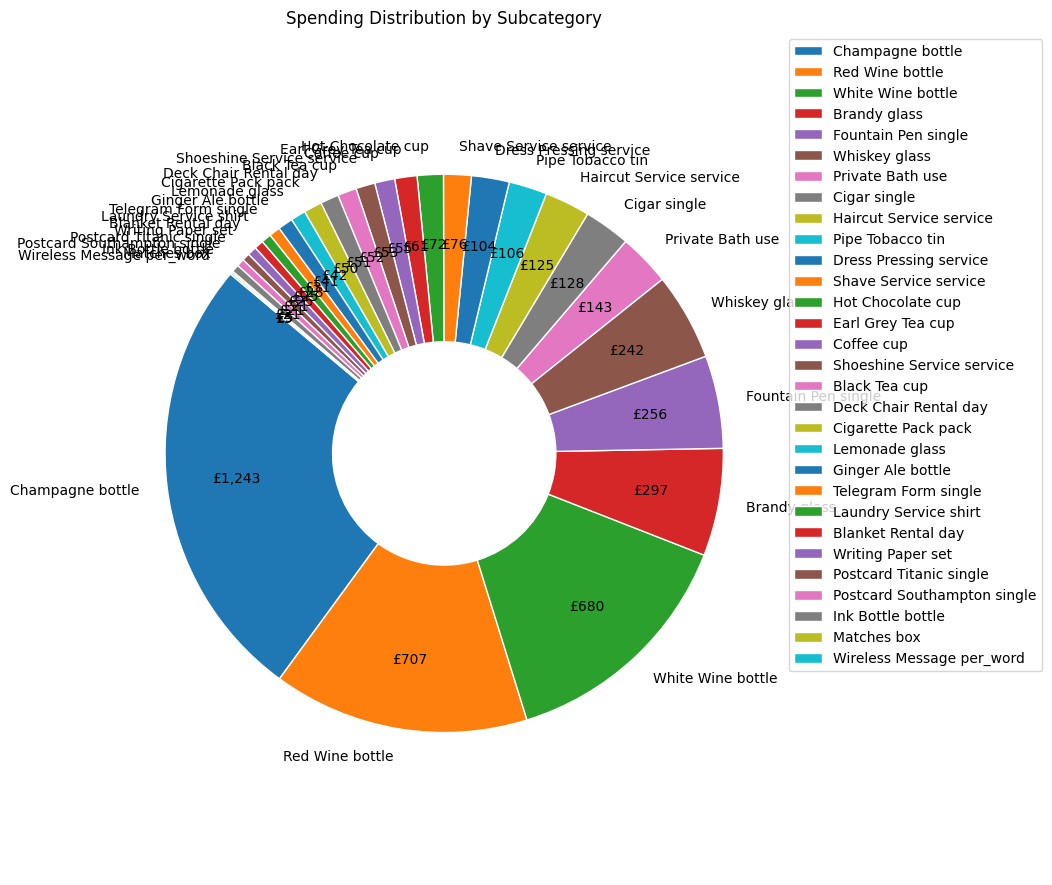

In [83]:
merged = pd.merge(all_data['titanic_purchases'], all_data['titanic_onboard_products'], on='product_id')
category_spending = merged.groupby('product_name')['final_amount_1912_gbp'].sum().sort_values(ascending=False)

total = category_spending.sum()

def make_autopct(values):
    def my_autopct(pct):
        absolute = int(round(pct * values.sum() / 100.0))
        return f'£{absolute:,}'
    return my_autopct

plt.figure(figsize=(9,9))
patches, texts, autotexts = plt.pie(
    category_spending,
    labels=category_spending.index,
    autopct=make_autopct(category_spending),
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor='w')
)

circle = plt.Circle((1,1), 0.0, fc='white')
fig = plt.gcf()
fig.add_artist(circle)

plt.title('Spending Distribution by Subcategory')
plt.axis('equal')
plt.tight_layout()
plt.legend(patches, category_spending.index, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


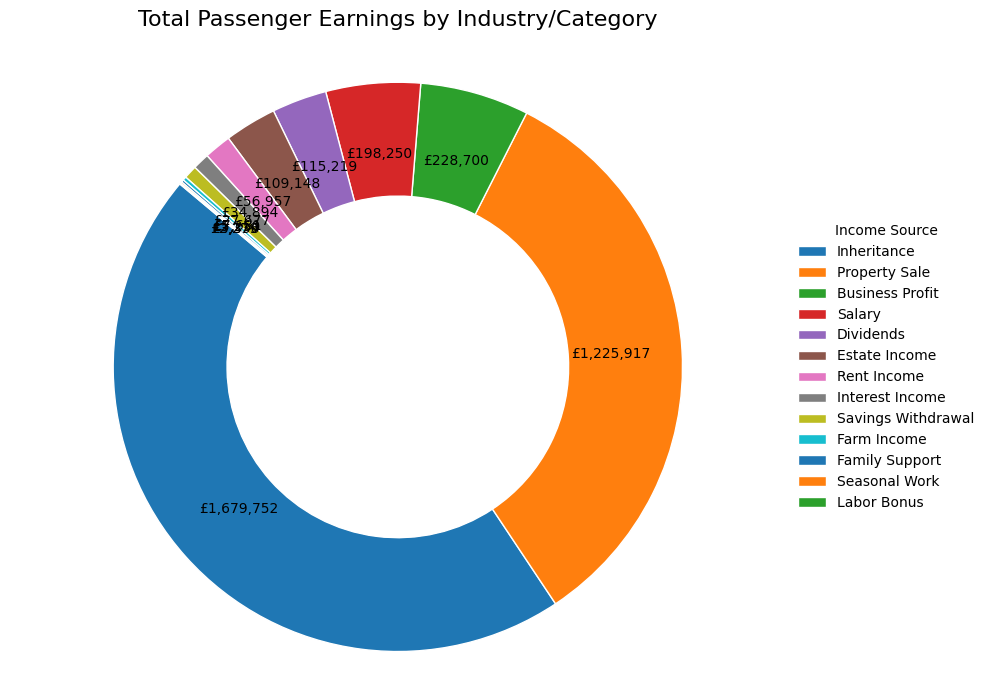

In [89]:
income_by_category = all_data['titanic_income_transactions'].groupby('income_category')['amount_gbp'].sum().sort_values(ascending=False)

def make_autopct(values):
    def my_autopct(pct):
        absolute = int(round(pct * values.sum() / 100.0))
        return f'£{absolute:,}'
    return my_autopct

plt.figure(figsize=(10, 7))

patches, texts, autotexts = plt.pie(
    income_by_category,
    labels=None, 
    autopct=make_autopct(income_by_category),
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='w')
)

centre_circle = plt.Circle((0,0), 0.6, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Total Passenger Earnings by Industry/Category', fontsize=16, pad=20)
plt.legend(patches, income_by_category.index, 
           title="Income Source", 
           loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1),
           frameon=False)

plt.axis('equal')
plt.tight_layout()
plt.show()

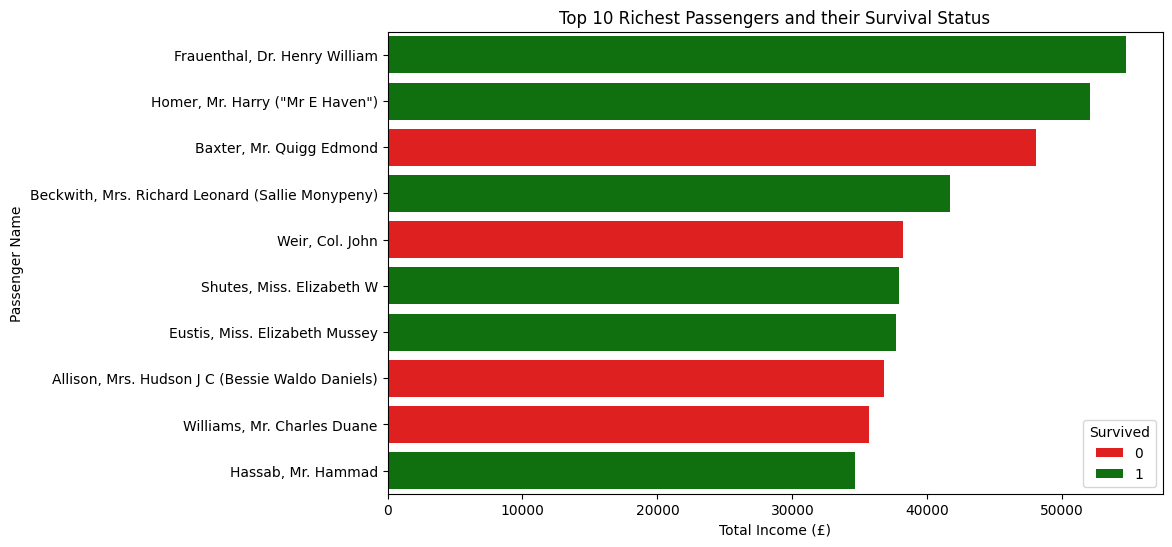

In [94]:
passenger_wealth = all_data['titanic_income_transactions'].groupby('PassengerId')['amount_gbp'].sum().reset_index()

top_10_rich = pd.merge(passenger_wealth, all_data['train'][['PassengerId', 'Name', 'Pclass', 'Survived']], on='PassengerId')

top_10_rich = top_10_rich.sort_values(by='amount_gbp', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top_10_rich, x='amount_gbp', y='Name', hue='Survived', palette={0: "red", 1: "green"})

plt.title('Top 10 Richest Passengers and their Survival Status')
plt.xlabel('Total Income (£)')
plt.ylabel('Passenger Name')
plt.show()

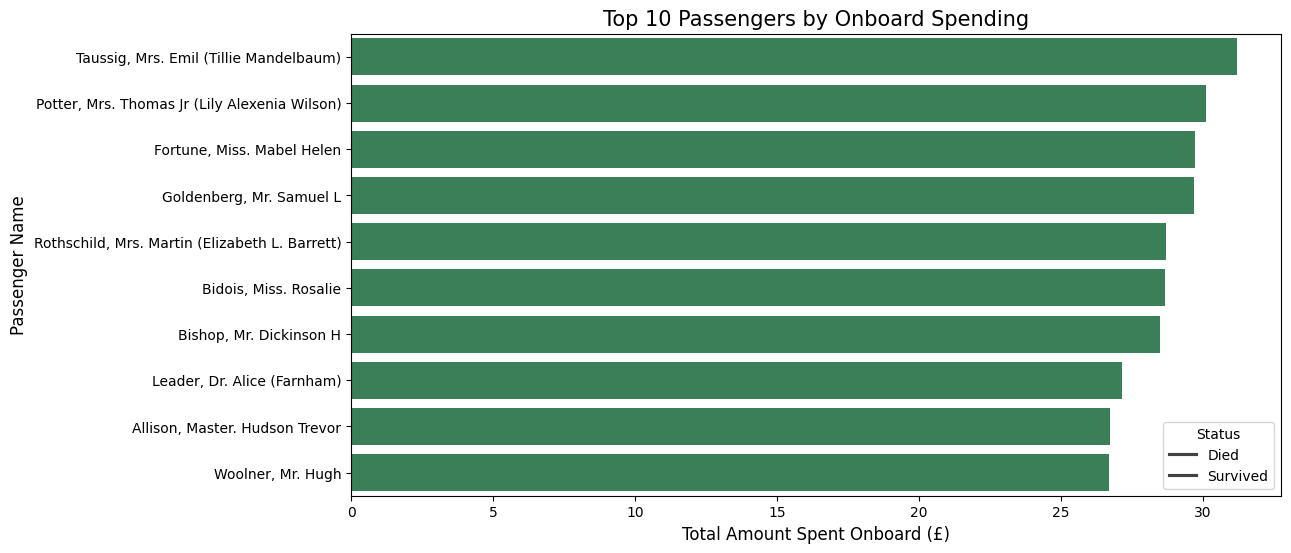

In [ ]:
spenders = all_data['titanic_purchases'].groupby('PassengerId')['final_amount_1912_gbp'].sum().reset_index()
top_spenders = pd.merge(spenders, all_data['train'][['PassengerId', 'Name', 'Survived', 'Pclass']], on='PassengerId')

top_10_spenders = top_spenders.sort_values(by='final_amount_1912_gbp', ascending=False).head(10)

top_10_survival_rate = top_10_spenders['Survived'].mean() * 100

plt.figure(figsize=(12, 6))
colors = {1: "seagreen", 0: "crimson"}

sns.barplot(
    data=top_10_spenders, 
    x='final_amount_1912_gbp', 
    y='Name', 
    hue='Survived', 
    palette=colors,
    dodge=False
)

plt.title('Top 10 Passengers by Onboard Spending', fontsize=15)
plt.xlabel('Total Amount Spent Onboard (£)', fontsize=12)
plt.ylabel('Passenger Name', fontsize=12)
plt.legend(title='Status', labels=['Died', 'Survived'])
plt.show()

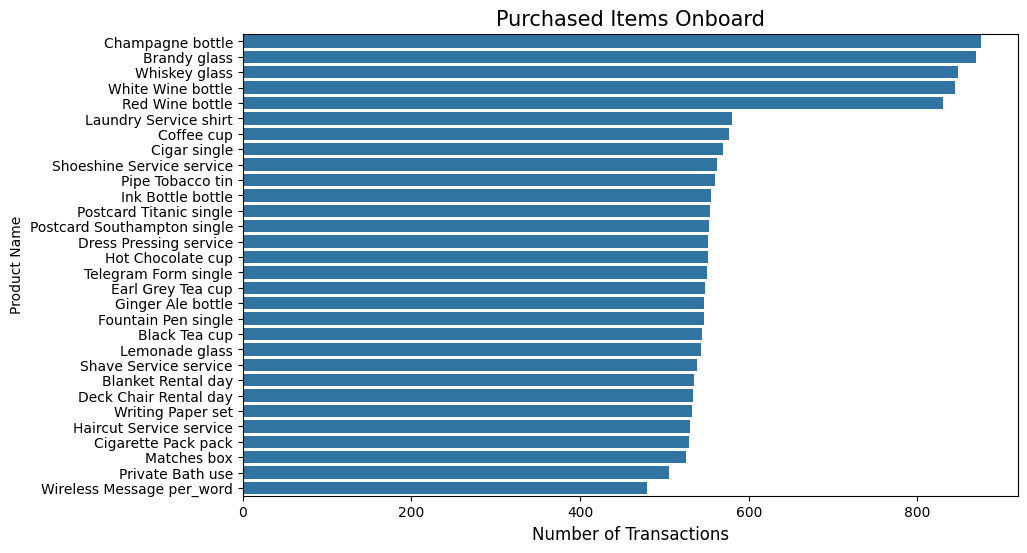

In [103]:
merged = pd.merge(all_data['titanic_purchases'], 
                  all_data['titanic_onboard_products'], 
                  on='product_id')

top_selling_products = merged.groupby('product_name').size().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_selling_products.values, 
            y=top_selling_products.index, )

plt.title('Purchased Items Onboard', fontsize=15)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Product Name', fontsize=10)
plt.show()

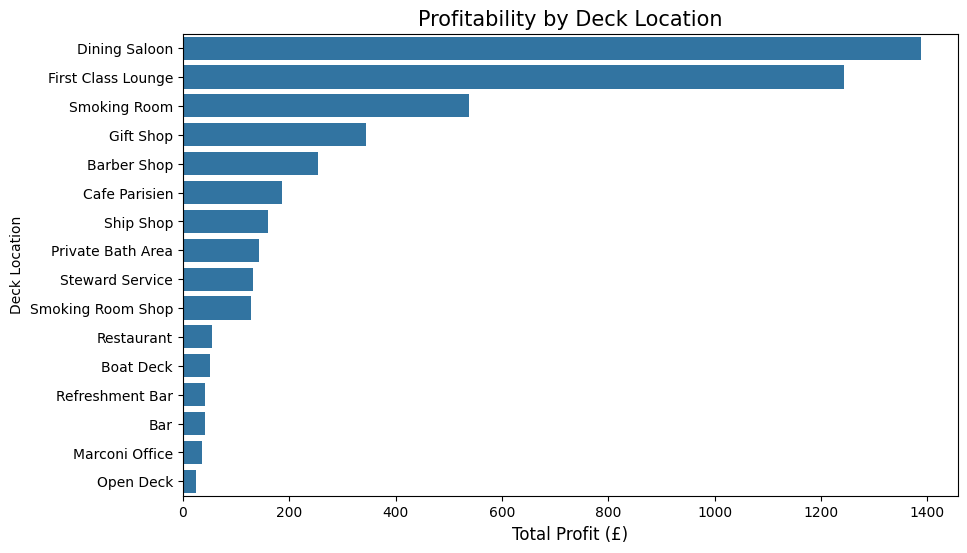

In [108]:
# Grouping by Deck (if available) to find the most profitable level
deck_profit = merged.groupby('deck_location')['final_amount_1912_gbp'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=deck_profit, 
            y=deck_profit.index, )

plt.title('Profitability by Deck Location', fontsize=15)
plt.xlabel('Total Profit (£)', fontsize=12)
plt.ylabel('Deck Location', fontsize=10)
plt.show()

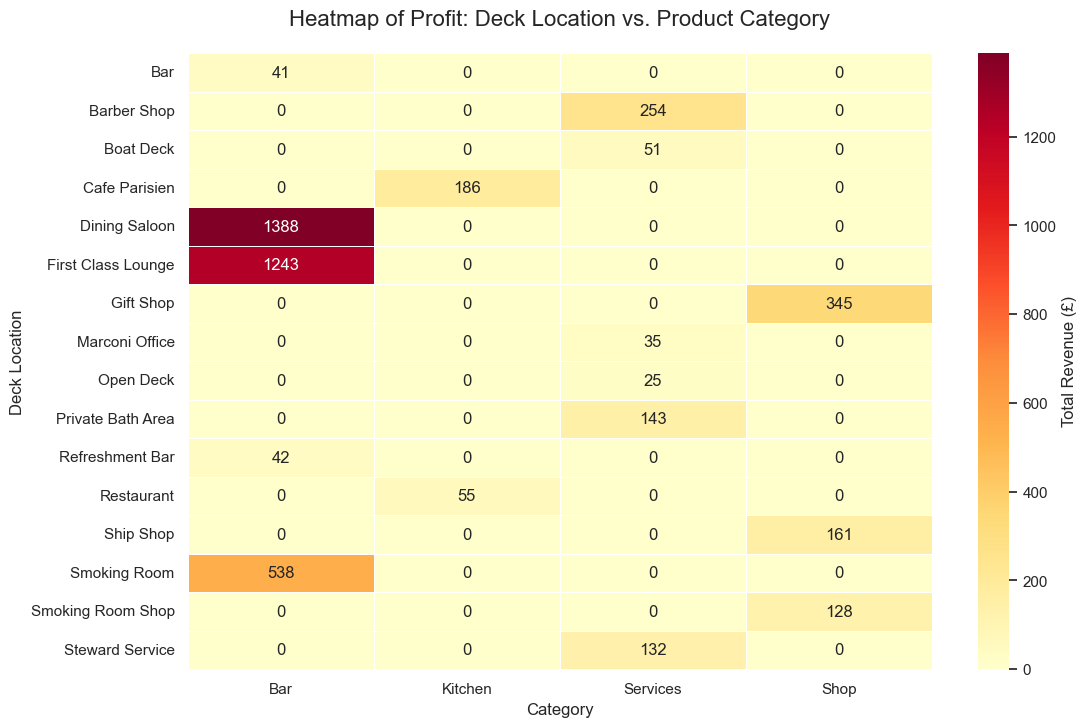

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_heat = pd.merge(
    all_data['titanic_purchases'], 
    all_data['titanic_onboard_products'], 
    on='product_id'
)

heatmap_data = df_heat.pivot_table(
    index='deck_location', 
    columns='category', 
    values='final_amount_1912_gbp', 
    aggfunc='sum'
).fillna(0) 

# 3. Строим тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,      
    fmt=".0f",       
    cmap="YlOrRd",   
    linewidths=.5,
    cbar_kws={'label': 'Total Revenue (£)'}
)

plt.title('Heatmap of Profit: Deck Location vs. Product Category', fontsize=16, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Deck Location', fontsize=12)
plt.show()